Dataset loaded. Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing values (post-fill):
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64

Train/Test split: (712, 7) (179, 7)

Running cross-validation for K=1..20


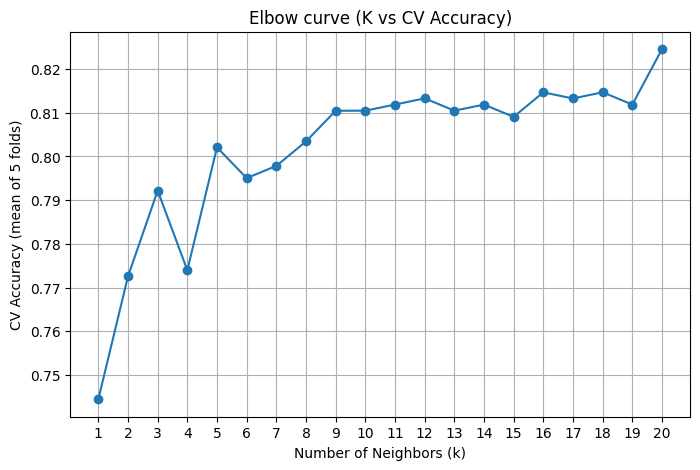


Best K by CV accuracy: K = 20 (CV accuracy = 0.8245)

Final model trained with K = 20

🎯 Accuracy: 0.7877

📊 Classification Report:
              precision    recall  f1-score   support

           0    0.78571   0.90000   0.83898       110
           1    0.79245   0.60870   0.68852        69

    accuracy                        0.78771       179
   macro avg    0.78908   0.75435   0.76375       179
weighted avg    0.78831   0.78771   0.78099       179



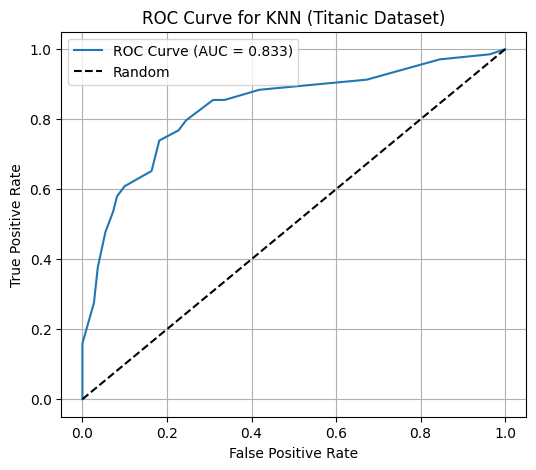


Decile summary (1 = top predicted decile):


,decile,total,responders,mean_prob,response_rate,lift
0,1,18,15,0.869444,0.833333,2.161836
1,2,18,15,0.744444,0.833333,2.161836
2,3,18,13,0.616667,0.722222,1.873591
3,4,18,8,0.472222,0.444444,1.152979
4,5,18,7,0.344444,0.388889,1.008857
5,6,17,3,0.226471,0.176471,0.457801
6,7,18,2,0.150000,0.111111,0.288245
7,8,18,1,0.133333,0.055556,0.144122
8,9,18,3,0.097222,0.166667,0.432367
9,10,18,2,0.036111,0.111111,0.288245


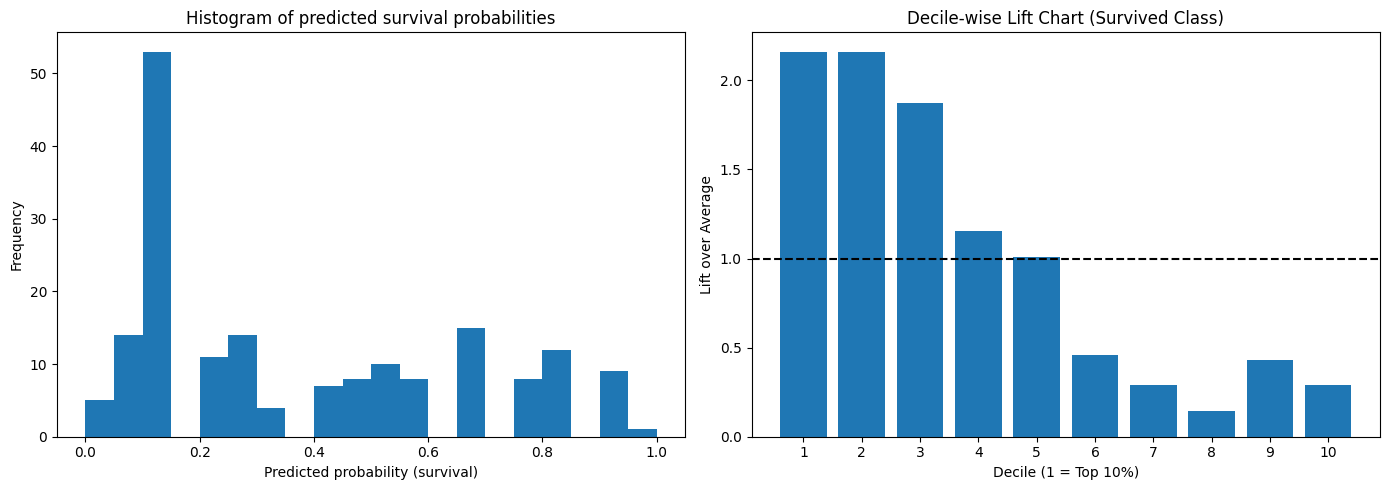


📈 Decile-wise Lift Table:
   decile  total  responders  mean_prob  response_rate      lift
0       1     18          15   0.869444       0.833333  2.161836
1       2     18          15   0.744444       0.833333  2.161836
2       3     18          13   0.616667       0.722222  1.873591
3       4     18           8   0.472222       0.444444  1.152979
4       5     18           7   0.344444       0.388889  1.008857
5       6     17           3   0.226471       0.176471  0.457801
6       7     18           2   0.150000       0.111111  0.288245
7       8     18           1   0.133333       0.055556  0.144122
8       9     18           3   0.097222       0.166667  0.432367
9      10     18           2   0.036111       0.111111  0.288245


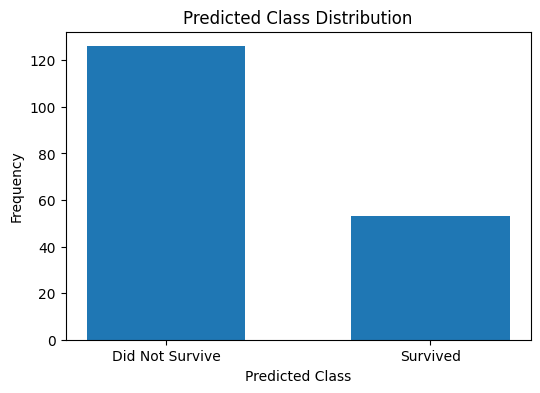


🔮 Prediction Example for New Passengers:
   Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Survival_Prob  \
0       3    male  22.0      1      0   7.2500        S           0.10   
1       1  female  38.0      1      0  71.2833        C           1.00   
2       2  female  27.0      0      0  13.0000        S           0.85   

   Predicted_Class  
0  Did Not Survive  
1         Survived  
2         Survived  

Sample of test-set predictions (first 10 rows):


,y_true,y_pred,y_proba
565,0,0,0.10
160,0,0,0.15
553,1,0,0.15
860,0,0,0.15
241,1,1,0.70
559,1,0,0.15
387,1,1,0.80
536,0,0,0.40
698,0,1,0.75
99,0,0,0.20



Interpretation:
1) The Elbow Curve (CV accuracy vs K) shows which K gives the best cross-validated accuracy; the K with the highest CV accuracy (printed above) is chosen as the best K.
2) Based on the test accuracy and the ROC AUC printed above, the KNN model has moderate predictive power — accuracy gives a basic correct/incorrect rate while ROC AUC (closer to 1 is better) reflects ranking quality; a high AUC (if observed) indicates the model discriminates survivors from non-survivors well, while a lower AUC suggests weaker discrimination.
3) From the Lift Chart and decile summary we can see whether the top deciles (decile 1 = highest predicted probabilities) contain a higher proportion of actual survivors than the overall rate — if decile 1 has substantially higher response_rate and lift > 1, the model is successfully concentrating survivors in the top deciles.
4) The example passengers’ predicted classes and probabilities give an individual-level sense of reliability: high predicted

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from IPython.display import display

# 1️⃣ Load Titanic dataset
url = "/content/Titanic.csv"
df = pd.read_csv(url)

print("Dataset loaded. Shape:", df.shape)
display(df.head())

# 2️⃣ Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Explicit - fill Fare if missing then check
if df['Fare'].isna().sum() > 0:
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())

print("\nMissing values (post-fill):")
print(df[features + [target]].isna().sum())

# 3️⃣ Define categorical and numerical columns
cat_cols = ['Sex', 'Embarked', 'Pclass']
num_cols = ['Age', 'SibSp', 'Parch', 'Fare']

# 4️⃣ Preprocessing pipeline
# NOTE: set handle_unknown='ignore' and request a dense output so KNN receives dense arrays
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])

# Pipeline for a given k
def make_pipeline_with_k(k):
    knn = KNeighborsClassifier(n_neighbors=k)
    pipe = Pipeline(steps=[('pre', preprocessor), ('knn', knn)])
    return pipe

# Prepare X and y
X = df[features]
y = df[target]

# 5️⃣ Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("\nTrain/Test split:", X_train.shape, X_test.shape)

# 6️⃣ Elbow Method
error_rate = []
K = list(range(1, 21))

print("\nRunning cross-validation for K=1..20")
for k in K:
    pipe = make_pipeline_with_k(k)
    #  cross_val_score on training set (5-fold)
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    error_rate.append(scores.mean())

# 👉 Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K, error_rate, marker='o', linestyle='-')
plt.title('Elbow curve (K vs CV Accuracy)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('CV Accuracy (mean of 5 folds)')
plt.xticks(K)
plt.grid(True)
plt.show()

# Choose best K
best_index = int(np.argmax(error_rate))
best_k = K[best_index]
best_score = error_rate[best_index]
print(f"\nBest K by CV accuracy: K = {best_k} (CV accuracy = {best_score:.4f})")

# 7️⃣ Train final KNN
model = make_pipeline_with_k(best_k)
model.fit(X_train, y_train)
print("\nFinal model trained with K =", best_k)

# 8️⃣ Accuracy + Classification report
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {acc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, digits=5))

# 9️⃣ ROC Curve
if hasattr(model.named_steps['knn'], "predict_proba"):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
    plt.plot([0,1],[0,1],'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for KNN (Titanic Dataset)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    # This will not happen for KNeighborsClassifier, but safe to include
    print("Model does not support predict_proba; skipping ROC/AUC.")
    y_prob = None

# 🔟 Decile-wise Lift Chart
# Compute deciles so Decile 1 = highest predicted probabilities (best prospects)
if y_prob is None:
    raise RuntimeError("No predicted probabilities available for lift chart.")
df_lift = pd.DataFrame({
    'actual': y_test.values,
    'prob': y_prob
}, index=y_test.index)
df_lift['rank_desc'] = df_lift['prob'].rank(method='first', ascending=False)
# qcut on rank ensures roughly equal-sized deciles; decile 1 will be top predicted
df_lift['decile'] = pd.qcut(df_lift['rank_desc'], q=10, labels=False) + 1

lift_table = df_lift.groupby('decile').agg(
    total = ('actual', 'count'),
    responders = ('actual', 'sum'),
    mean_prob = ('prob', 'mean')
).reset_index().sort_values('decile')

lift_table['response_rate'] = lift_table['responders'] / lift_table['total']
overall_rate = df_lift['actual'].mean()
lift_table['lift'] = lift_table['response_rate'] / overall_rate

print("\nDecile summary (1 = top predicted decile):")
display(lift_table)

# 1️⃣1️⃣ Plot Histogram + Decile-wise Lift
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of predicted probabilities (recommended)
axes[0].hist(df_lift['prob'], bins=20)
axes[0].set_title('Histogram of predicted survival probabilities')
axes[0].set_xlabel('Predicted probability (survival)')
axes[0].set_ylabel('Frequency')

# Lift Chart
axes[1].bar(lift_table['decile'], lift_table['lift'])
axes[1].set_title('Decile-wise Lift Chart (Survived Class)')
axes[1].set_xlabel('Decile (1 = Top 10%)')
axes[1].set_ylabel('Lift over Average')
axes[1].axhline(1, color='black', linestyle='--')
axes[1].set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

print("\n📈 Decile-wise Lift Table:")
print(lift_table)

# Additionally keep class distribution histogram if you want
plt.figure(figsize=(6,4))
plt.hist(y_pred, bins=[-0.5, 0.5, 1.5], rwidth=0.6)
plt.xticks([0,1], ['Did Not Survive', 'Survived'])
plt.title('Predicted Class Distribution')
plt.xlabel('Predicted Class')
plt.ylabel('Frequency')
plt.show()

# 1️⃣2️⃣ Example: Predict survival for new passengers
new_passengers = pd.DataFrame([
    # Ex 1
    {'Pclass': 3, 'Sex': 'male',   'Age': 22.0, 'SibSp': 1, 'Parch': 0, 'Fare': 7.25,  'Embarked': 'S'},
    # Ex 2
    {'Pclass': 1, 'Sex': 'female', 'Age': 38.0, 'SibSp': 1, 'Parch': 0, 'Fare': 71.2833, 'Embarked': 'C'},
    # Ex 3
    {'Pclass': 2, 'Sex': 'female', 'Age': 27.0, 'SibSp': 0, 'Parch': 0, 'Fare': 13.0,   'Embarked': 'S'}
])

new_passengers = new_passengers[features]

pred_class = model.predict(new_passengers)
pred_prob = model.predict_proba(new_passengers)[:, 1]

# Combine into a result table
results = new_passengers.copy()
results['Survival_Prob'] = pred_prob
results['Predicted_Class'] = ['Survived' if p == 1 else 'Did Not Survive' for p in pred_class]

print("\n🔮 Prediction Example for New Passengers:")
print(results)

# Combine into a result table (test set predictions + their probabilities)
test_results = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'y_proba': y_prob
})
print("\nSample of test-set predictions (first 10 rows):")
display(test_results.head(10))

# Short interpretation (5-7 sentences) answering the required questions:
interpretation = """
Interpretation:
1) The Elbow Curve (CV accuracy vs K) shows which K gives the best cross-validated accuracy; the K with the highest CV accuracy (printed above) is chosen as the best K.
2) Based on the test accuracy and the ROC AUC printed above, the KNN model has moderate predictive power — accuracy gives a basic correct/incorrect rate while ROC AUC (closer to 1 is better) reflects ranking quality; a high AUC (if observed) indicates the model discriminates survivors from non-survivors well, while a lower AUC suggests weaker discrimination.
3) From the Lift Chart and decile summary we can see whether the top deciles (decile 1 = highest predicted probabilities) contain a higher proportion of actual survivors than the overall rate — if decile 1 has substantially higher response_rate and lift > 1, the model is successfully concentrating survivors in the top deciles.
4) The example passengers’ predicted classes and probabilities give an individual-level sense of reliability: high predicted probabilities (close to 1 or 0) are more confident, while probabilities near 0.5 are less reliable.
Overall, use accuracy + ROC + the lift by decile together to judge whether the model is useful for prioritization (e.g., identifying likely survivors) rather than relying on any single metric.
"""
print(interpretation)
